In [25]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')


RANDOM_STATE = 42


In [26]:
from google.colab import files

print("Please upload train.csv, test.csv, and sample_submission.csv")
uploaded = files.upload()


Please upload train.csv, test.csv, and sample_submission.csv


Saving sample_submission.csv to sample_submission (2).csv
Saving test.csv to test (2).csv
Saving train.csv to train (2).csv


In [27]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [28]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


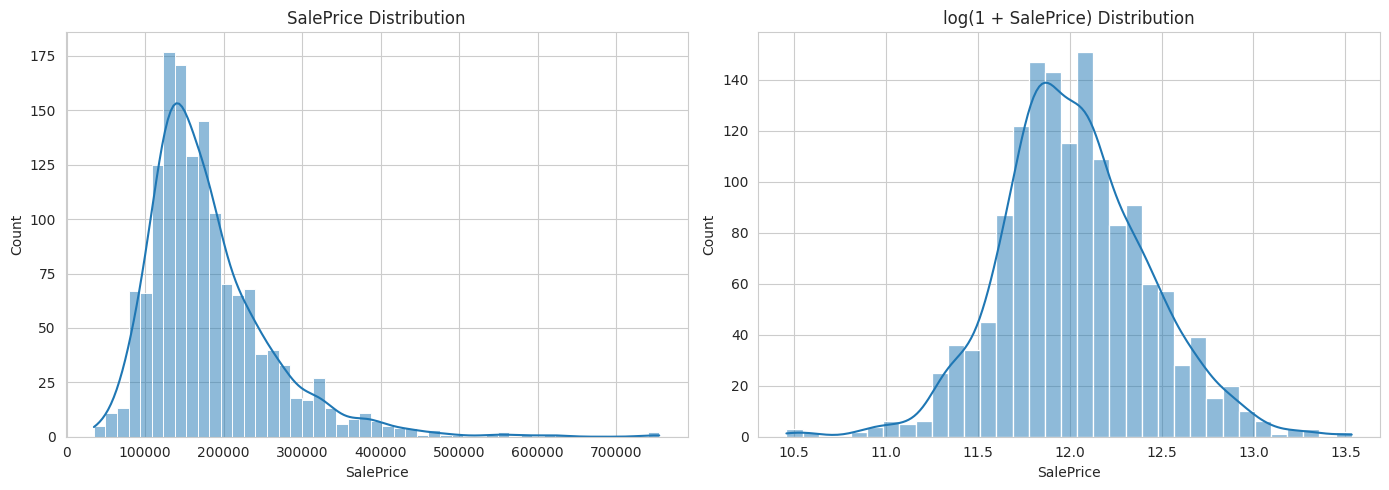

Skewness of SalePrice: 1.88
Skewness of log(SalePrice): 0.12


In [29]:

print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')

sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('log(1 + SalePrice) Distribution')
plt.tight_layout()
plt.show()

print("Skewness of SalePrice:", train['SalePrice'].skew().round(2))
print("Skewness of log(SalePrice):", np.log1p(train['SalePrice']).skew().round(2))


              missing_count  missing_pct
PoolQC                 1453         99.5
MiscFeature            1406         96.3
Alley                  1369         93.8
Fence                  1179         80.8
MasVnrType              872         59.7
FireplaceQu             690         47.3
LotFrontage             259         17.7
GarageType               81          5.5
GarageYrBlt              81          5.5
GarageFinish             81          5.5
GarageQual               81          5.5
GarageCond               81          5.5
BsmtExposure             38          2.6
BsmtFinType2             38          2.6
BsmtQual                 37          2.5
BsmtCond                 37          2.5
BsmtFinType1             37          2.5
MasVnrArea                8          0.5
Electrical                1          0.1


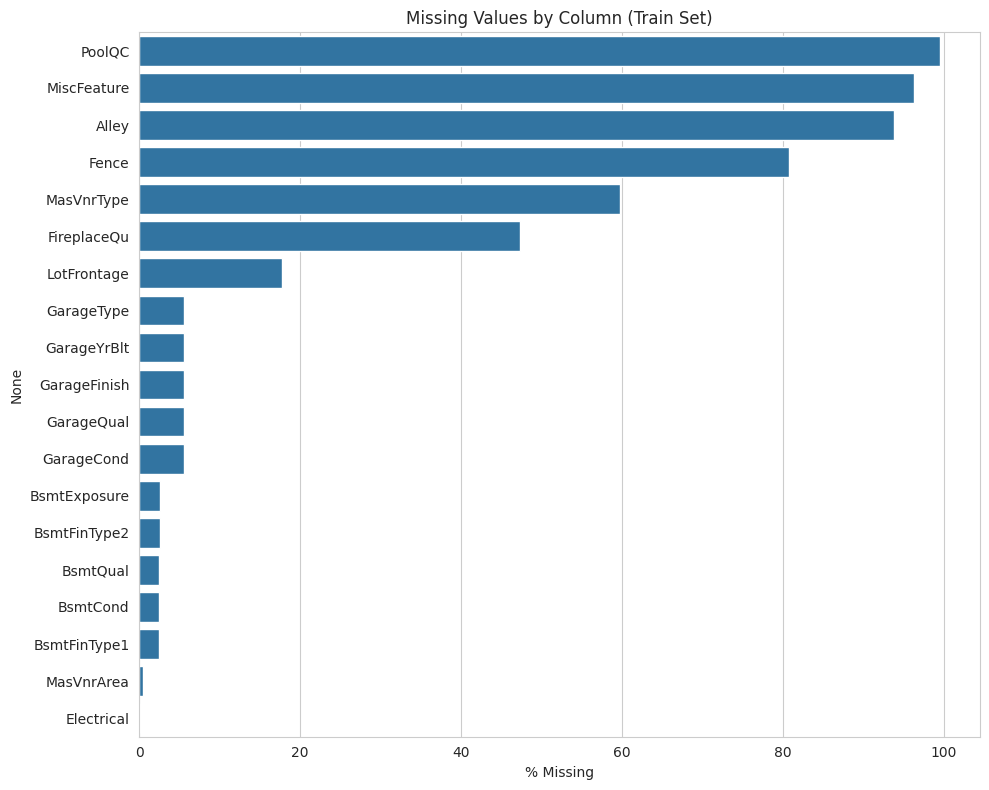

In [30]:

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df)

plt.figure(figsize=(10, 8))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel('% Missing')
plt.title('Missing Values by Column (Train Set)')
plt.tight_layout()
plt.show()


SalePrice       1.000000
OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
YearBuilt       0.523608
YearRemodAdd    0.507717
GarageYrBlt     0.487156
MasVnrArea      0.482719
Fireplaces      0.469862
BsmtFinSF1      0.409384
Name: SalePrice, dtype: float64


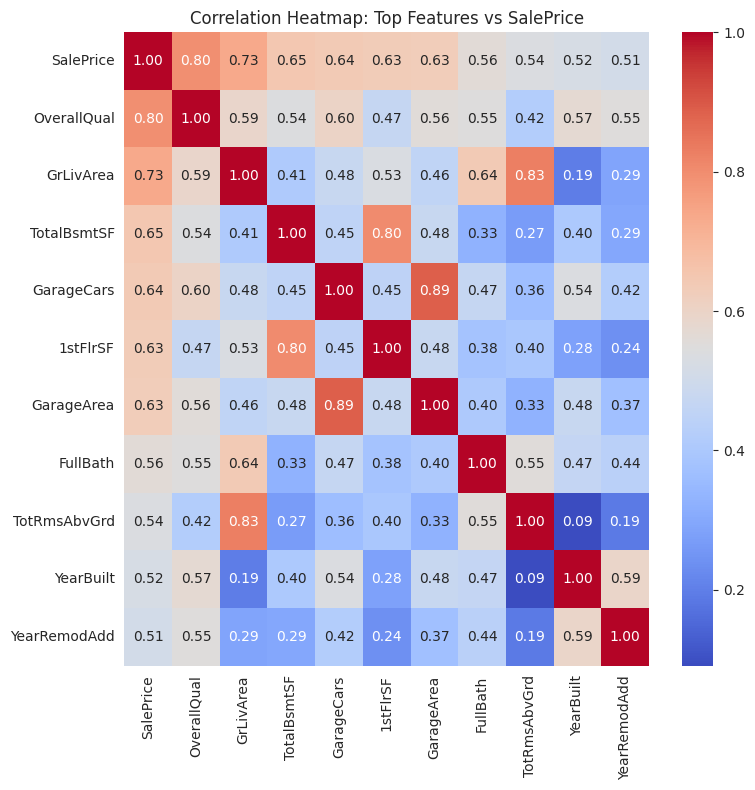

In [23]:

numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(15))

plt.figure(figsize=(8, 8))
top_corr_features = corr.head(11).index
sns.heatmap(train[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap: Top Features vs SalePrice')
plt.tight_layout()
plt.show()


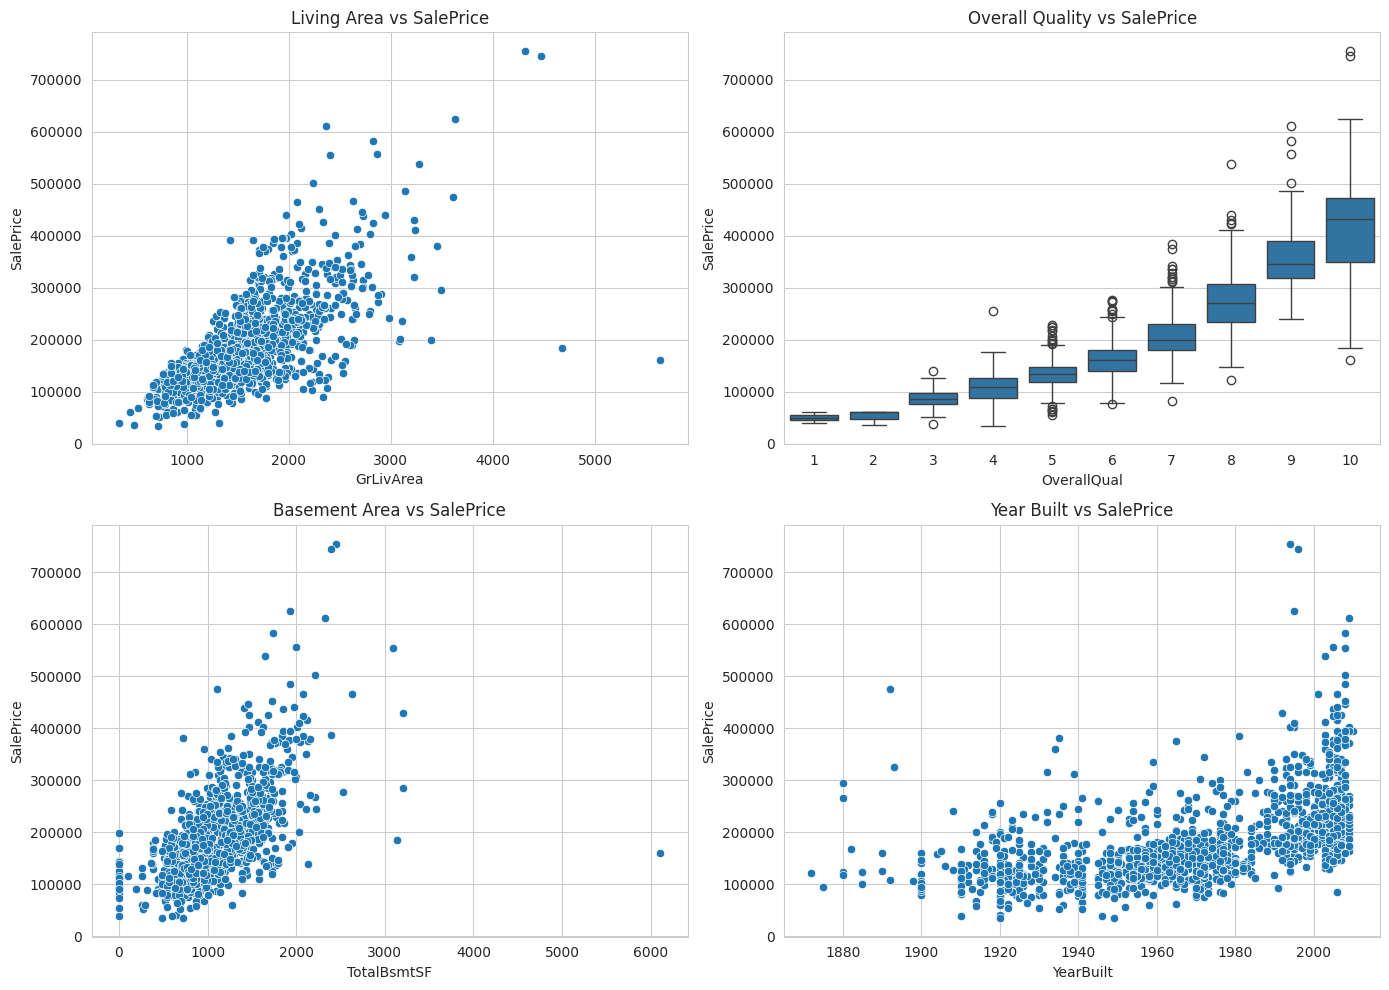

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', ax=axes[0, 0])
axes[0, 0].set_title('Living Area vs SalePrice')

sns.boxplot(data=train, x='OverallQual', y='SalePrice', ax=axes[0, 1])
axes[0, 1].set_title('Overall Quality vs SalePrice')

sns.scatterplot(data=train, x='TotalBsmtSF', y='SalePrice', ax=axes[1, 0])
axes[1, 0].set_title('Basement Area vs SalePrice')

sns.scatterplot(data=train, x='YearBuilt', y='SalePrice', ax=axes[1, 1])
axes[1, 1].set_title('Year Built vs SalePrice')

plt.tight_layout()
plt.show()


In [34]:

outlier_idx = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
print(f"Removing {len(outlier_idx)} outlier rows")
train = train.drop(outlier_idx).reset_index(drop=True)
print("New train shape:", train.shape)


Removing 2 outlier rows
New train shape: (1458, 81)


In [33]:

train_ID = train['Id']
test_ID = test['Id']

y = np.log1p(train['SalePrice'])

train_features = train.drop(['Id', 'SalePrice'], axis=1)
test_features = test.drop(['Id'], axis=1)

n_train = train_features.shape[0]
all_data = pd.concat([train_features, test_features], axis=0).reset_index(drop=True)
print("Combined data shape:", all_data.shape)


Combined data shape: (2919, 79)


In [35]:

none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)


all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'] \
    .transform(lambda x: x.fillna(x.median()))

mode_cols = ['MSZoning', 'Utilities', 'Functional', 'Electrical',
             'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print("Remaining missing values:", all_data.isnull().sum().sum())


Remaining missing values: 0


In [36]:

all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                               all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)


all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)

print("Shape after feature engineering:", all_data.shape)


Shape after feature engineering: (2919, 87)


In [13]:
categorical_cols = all_data.select_dtypes(include=['object']).columns
print(f"{len(categorical_cols)} categorical columns")

all_data = pd.get_dummies(all_data, columns=categorical_cols, drop_first=True)
print("Shape after one-hot encoding:", all_data.shape)


44 categorical columns
Shape after one-hot encoding: (2917, 280)


In [14]:

X = all_data.iloc[:n_train, :].copy()
X_test_final = all_data.iloc[n_train:, :].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_test_final_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns, index=X_test_final.index)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, " X_val:", X_val.shape)


X_train: (1166, 280)  X_val: (292, 280)


In [15]:
def rmse_cv(model, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kf)
    return np.sqrt(-scores)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=None,
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                    max_depth=3, random_state=RANDOM_STATE),
}

cv_results = {}
for name, model in models.items():
    scores = rmse_cv(model, X_scaled, y)
    cv_results[name] = scores
    print(f"{name:20s}  CV RMSE (log-price): {scores.mean():.4f} (+/- {scores.std():.4f})")


Linear Regression     CV RMSE (log-price): 0.1349 (+/- 0.0153)
Ridge                 CV RMSE (log-price): 0.1295 (+/- 0.0149)
Lasso                 CV RMSE (log-price): 0.1235 (+/- 0.0118)
Random Forest         CV RMSE (log-price): 0.1372 (+/- 0.0074)
Gradient Boosting     CV RMSE (log-price): 0.1267 (+/- 0.0082)


/tmp/ipykernel_5105/4294275024.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


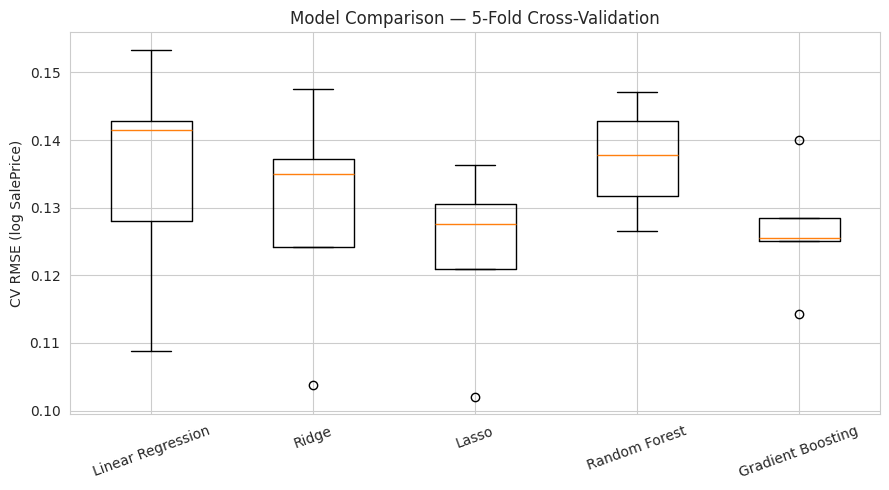

In [16]:
plt.figure(figsize=(9, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel('CV RMSE (log SalePrice)')
plt.title('Model Comparison — 5-Fold Cross-Validation')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [17]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    preds_log = model.predict(X_val)

    rmse_log = np.sqrt(mean_squared_error(y_val, preds_log))
    mae_log = mean_absolute_error(y_val, preds_log)
    r2 = r2_score(y_val, preds_log)


    preds_dollars = np.expm1(preds_log)
    y_val_dollars = np.expm1(y_val)
    rmse_dollars = np.sqrt(mean_squared_error(y_val_dollars, preds_dollars))
    mae_dollars = mean_absolute_error(y_val_dollars, preds_dollars)

    results.append({
        'Model': name,
        'RMSE (log)': rmse_log,
        'MAE (log)': mae_log,
        'R2': r2,
        'RMSE ($)': rmse_dollars,
        'MAE ($)': mae_dollars,
    })

results_df = pd.DataFrame(results).sort_values('RMSE (log)').reset_index(drop=True)
results_df


,Model,RMSE (log),MAE (log),R2,RMSE ($),MAE ($)
0,Gradient Boosting,0.125538,0.084855,0.906513,20453.516713,14459.142539
1,Lasso,0.130512,0.087860,0.898957,21302.329788,14805.573500
2,Ridge,0.134948,0.091262,0.891972,21811.370613,15296.307480
3,Linear Regression,0.141533,0.094160,0.881172,22308.980367,15582.547489
4,Random Forest,0.146938,0.098227,0.871923,23867.313944,16644.861989


Best model on validation set: Gradient Boosting


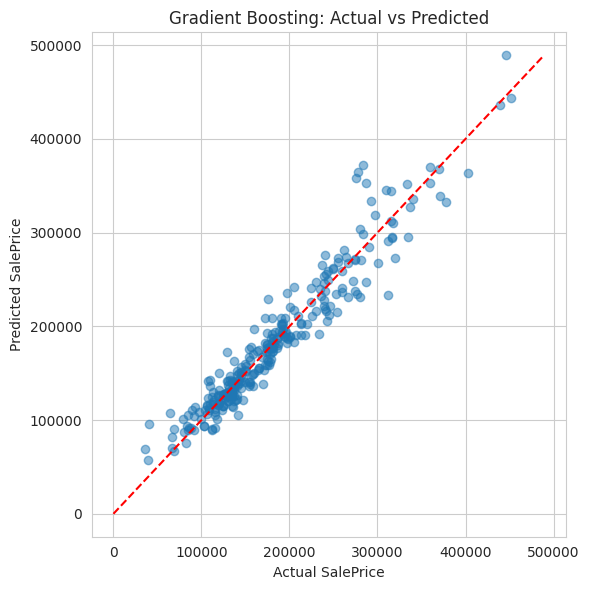

In [18]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model on validation set: {best_model_name}")

best_model = fitted_models[best_model_name]
preds_val = best_model.predict(X_val)

plt.figure(figsize=(6, 6))
plt.scatter(np.expm1(y_val), np.expm1(preds_val), alpha=0.5)
lims = [0, max(np.expm1(y_val).max(), np.expm1(preds_val).max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title(f'{best_model_name}: Actual vs Predicted')
plt.tight_layout()
plt.show()


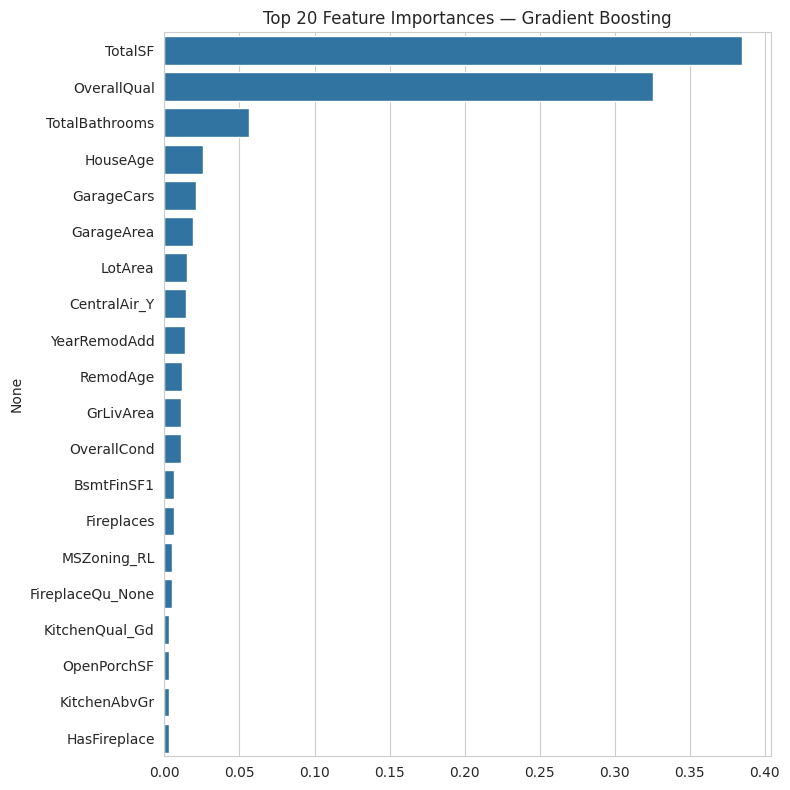

In [19]:

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top20 = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(8, 8))
    sns.barplot(x=top20.values, y=top20.index)
    plt.title(f'Top 20 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_, index=X_train.columns)
    top20 = coefs.abs().sort_values(ascending=False).head(20).index
    plt.figure(figsize=(8, 8))
    sns.barplot(x=coefs[top20].values, y=top20)
    plt.title(f'Top 20 Coefficients (by magnitude) — {best_model_name}')
    plt.tight_layout()
    plt.show()


In [22]:

final_model = fitted_models[best_model_name].__class__(**fitted_models[best_model_name].get_params())
final_model.fit(X_scaled, y)

test_preds_log = final_model.predict(X_test_final_scaled)
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({'Id': test_ID, 'SalePrice': test_preds})
submission.to_csv('submission.csv', index=False)
submission.head()


,Id,SalePrice
0,1461,123341.098070
1,1462,159928.396690
2,1463,183627.835171
3,1464,189652.907165
4,1465,191004.133656


In [21]:
from google.colab import files
files.download('submission.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>